In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

from data import get_y, get_dataloader
from config_mounir import NearOODFramework
from eval_functions import train, auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite, performance_report

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Préparation des données

In [ ]:
framework = NearOODFramework()
dataset_id, dataset_ood = framework.get_confs("id", "ash"), framework.get_confs("ood","ash")
X = np.vstack([dataset_id, dataset_ood])
Y = get_y(dataset_id, dataset_ood)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                X, Y, stratify=Y, test_size=0.2, random_state=42)

data = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

# with open("data_vfa.pkl", 'wb') as f:
#     pickle.dump(data, f)

# Chargement des données

In [3]:
with open('data_vfa.pkl', 'rb') as f:
    data = pickle.load(f)

train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))
372 elements (array([0., 1.], dtype=float32), array([107, 265]))


# Modèle

In [6]:
input_dim = 5 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(data['y_train'], return_counts=True) ### Entrainement avec pondération)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.4066350710900474

In [ ]:
model = nn.Linear(input_dim, output_dim)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr = 0.2 # j'ai essayé tout ça [0.5, 1, 1.5, 2] avec SGD et scheduler mais rien n'améliore, max 0.6 et souvent l'entraînement est instable
optim = torch.optim.SGD(model.parameters(), lr=lr)
nb_epochs = 1000

# Entrainement

cuda


/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/torch/nn/functional.py:1944: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


accuracy train:  0.5921395272016525


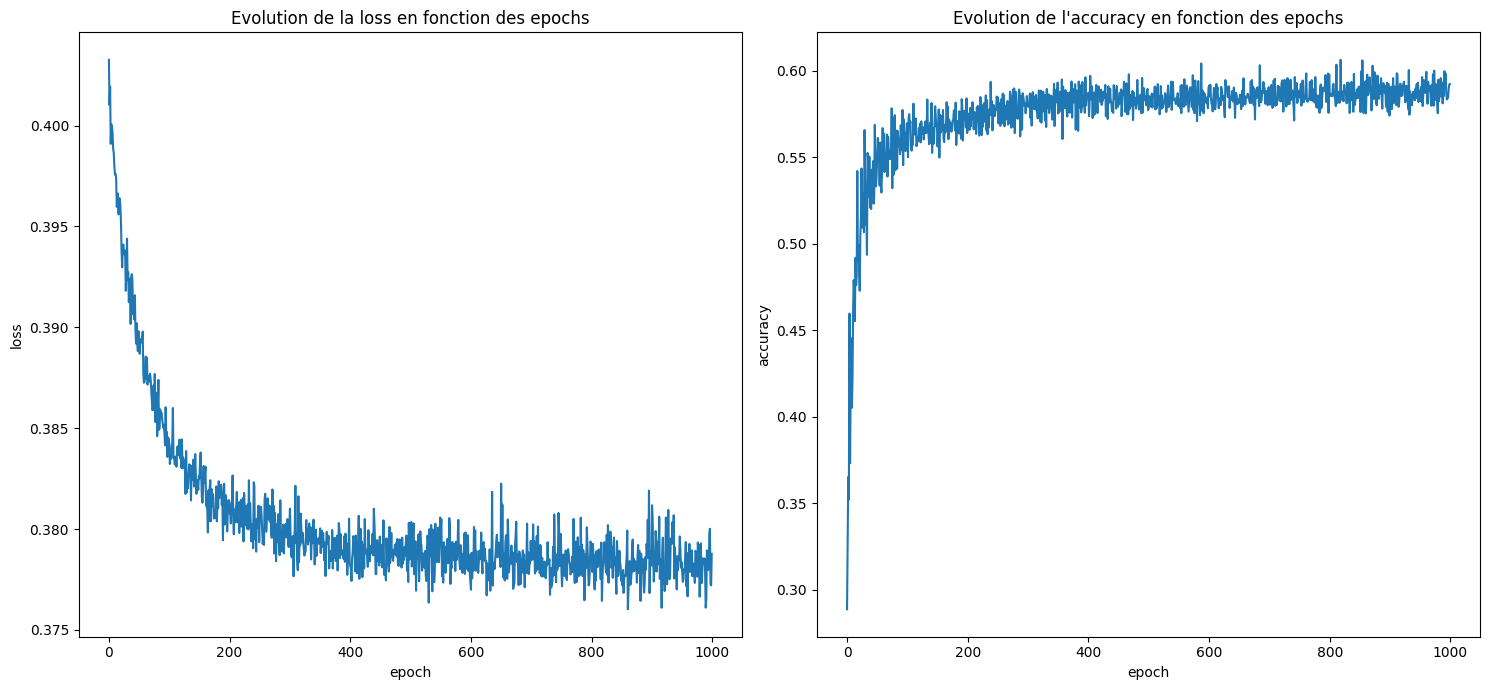

In [31]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs=nb_epochs)
visualize(plot_loss, plot_acc)

In [35]:
torch.save(model.state_dict(), "model_vfa.pth")

In [32]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-1.0217,  0.0498, -1.0293, -1.6541, -0.5312]], device='cuda:0')
bias
tensor([3.5832], device='cuda:0')


# Tests

In [8]:
input_dim = 5 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

model.load_state_dict(torch.load("model_vfa.pth"))

<All keys matched successfully>

Accuracy test:  0.7124
Séparabilité:


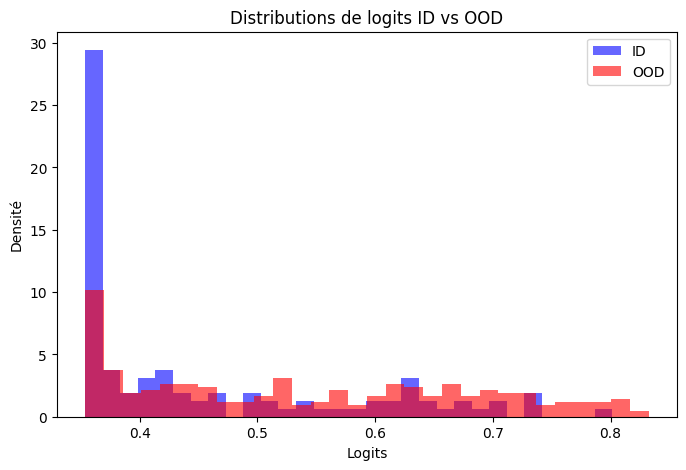

AUC ROC: 0.7062
FPR@TPR95: 0.729

Correlation ID :  0.836502030526902
Correlation OOD :  0.9412171260991948


,config,tout,video,flow,audio
0,poids_vfa,0.0498,-1.0293,-1.6541,-0.5312
1,perturbation_vfa_id,0.0246,0.0100,0.0053,0.0078
2,perturbation_vfa_ood,0.0134,0.0059,0.0012,0.0058


In [9]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("vfa"))

# Modèle 2 Couches

cuda
accuracy train:  0.709121435880661


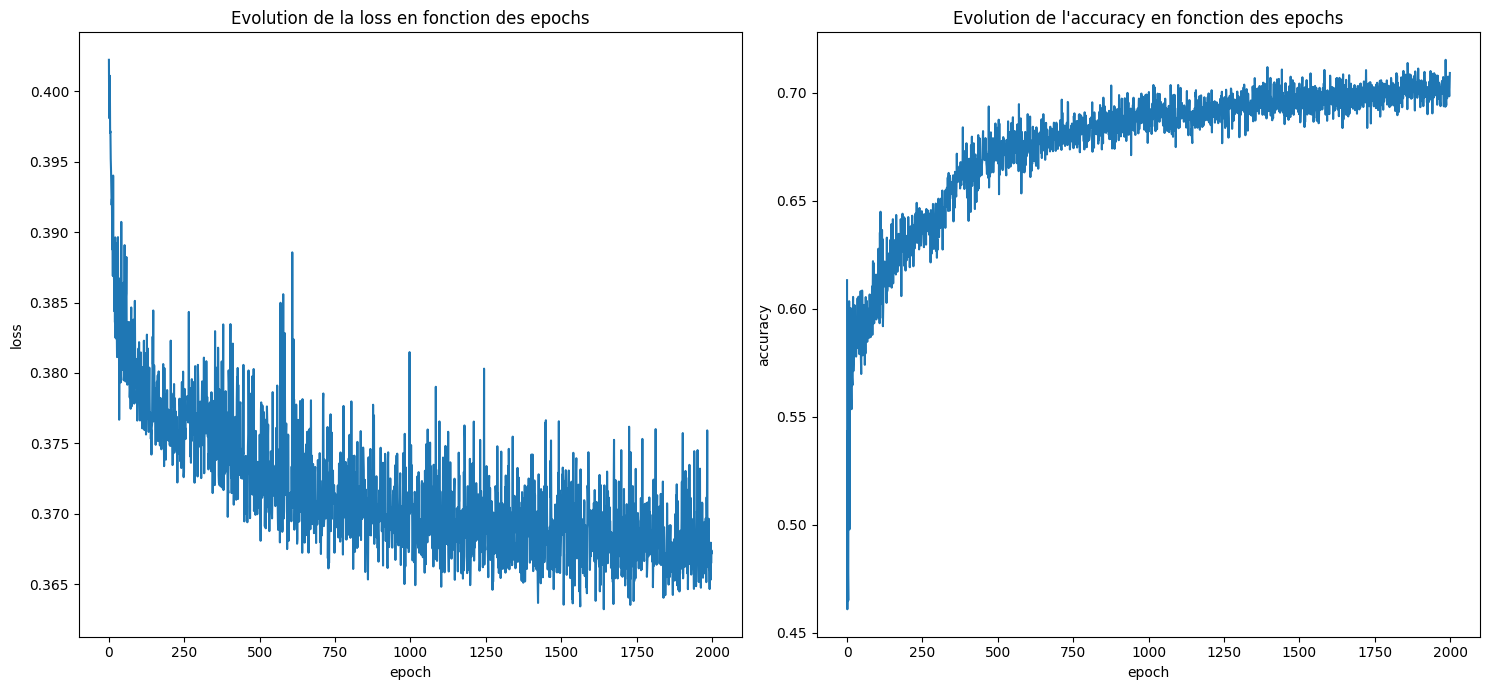

In [32]:
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=1
nb_epochs = 2000
optim = torch.optim.SGD(model.parameters(), lr)

plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs=nb_epochs)
visualize(plot_loss, plot_acc)

In [33]:
torch.save(model.state_dict(), "model_near_vfa_2c.pth")

## Tests

In [10]:
input_dim = 5 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

model.load_state_dict(torch.load("model_near_vfa_2c.pth"))

<All keys matched successfully>

Accuracy test:  0.7124
Séparabilité:


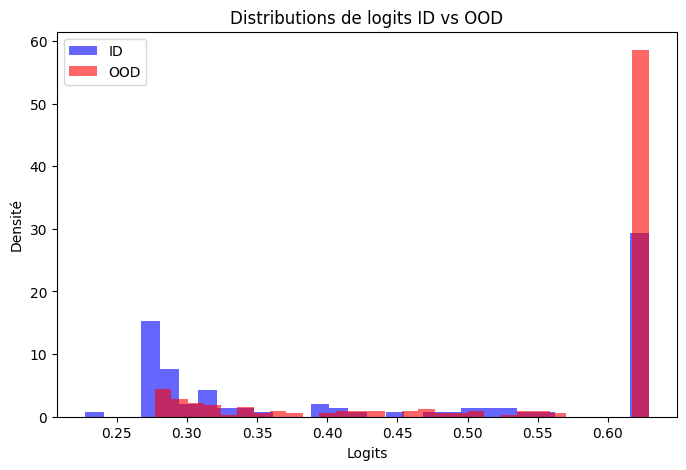

AUC ROC: 0.6791
FPR@TPR95: 0.729



In [11]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("vfa"), correlations=False)